### Worked example of a quant tree

Display a single example of the combined tree + log2 fold-change plot inline using the packaged example data.
- **Requirements**: next to the default alphaquant installation, it is necessary to install graphviz and pygraphviz in order to run this notebook

- **Data source**: `./data/example_tree_data` (contains `samples.map.tsv` and `iontrees.json`, `normed.tsv`, `results.tsv`). These are produced by a standard AlphaQuant run.
- **Workflow**:
  - Imports `alphaquant` from the repository.
  - Loads the `S1` vs `S2` condition-pair tree and quantification info.
  - Chooses protein `P0A6R0` (or change to any available protein ID).
  - Creates a `CombinedTreeAndFCPlotter` and displays the figure inline.
- **Annotations**:
  - Node labels are annotated with statistical values (enabled in the code via `show_node_annotations=True`).
  - Default attributes shown: `p_val`, `z_val`, `fc` with formatting `p={:.2e}`, `z={:.2f}`, `log2fc={:.2f}`.
  - Other available attributes you can add: `cluster`, `ml_score`, `cv`, `min_intensity`, `total_intensity`, `min_reps`, `fraction_consistent`, `is_included`, `missingval`.
- **Customize**:
  - Change the protein: edit `example_protein = "YOUR_PROTEIN_ID"` in the code cell.
  - Change which attributes are shown: edit `node_annotation_attributes=[...]` and `node_annotation_formats={...}`.
  - Adjust layout/font size: tweak `rescale_factor_x`, `rescale_factor_y`, and `node_fontsize` in `PlotConfig`.
  - Switch tree granularity with `tree_level` (`"seq"`, `"mod_seq"`, `"mod_seq_charge"`, `"ion_type"`).


/Users/constantin/workspace/alphaquant/alphaquant/plotting/fcviz.py:682: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  precursor = df_c1.loc[ion]["specified_level"][0]
2025-08-10 20:29:11,803 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-10 20:29:11,806 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/Users/constantin/workspace/alphaquant/alphaquant/plotting/fcviz.py:682: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a 

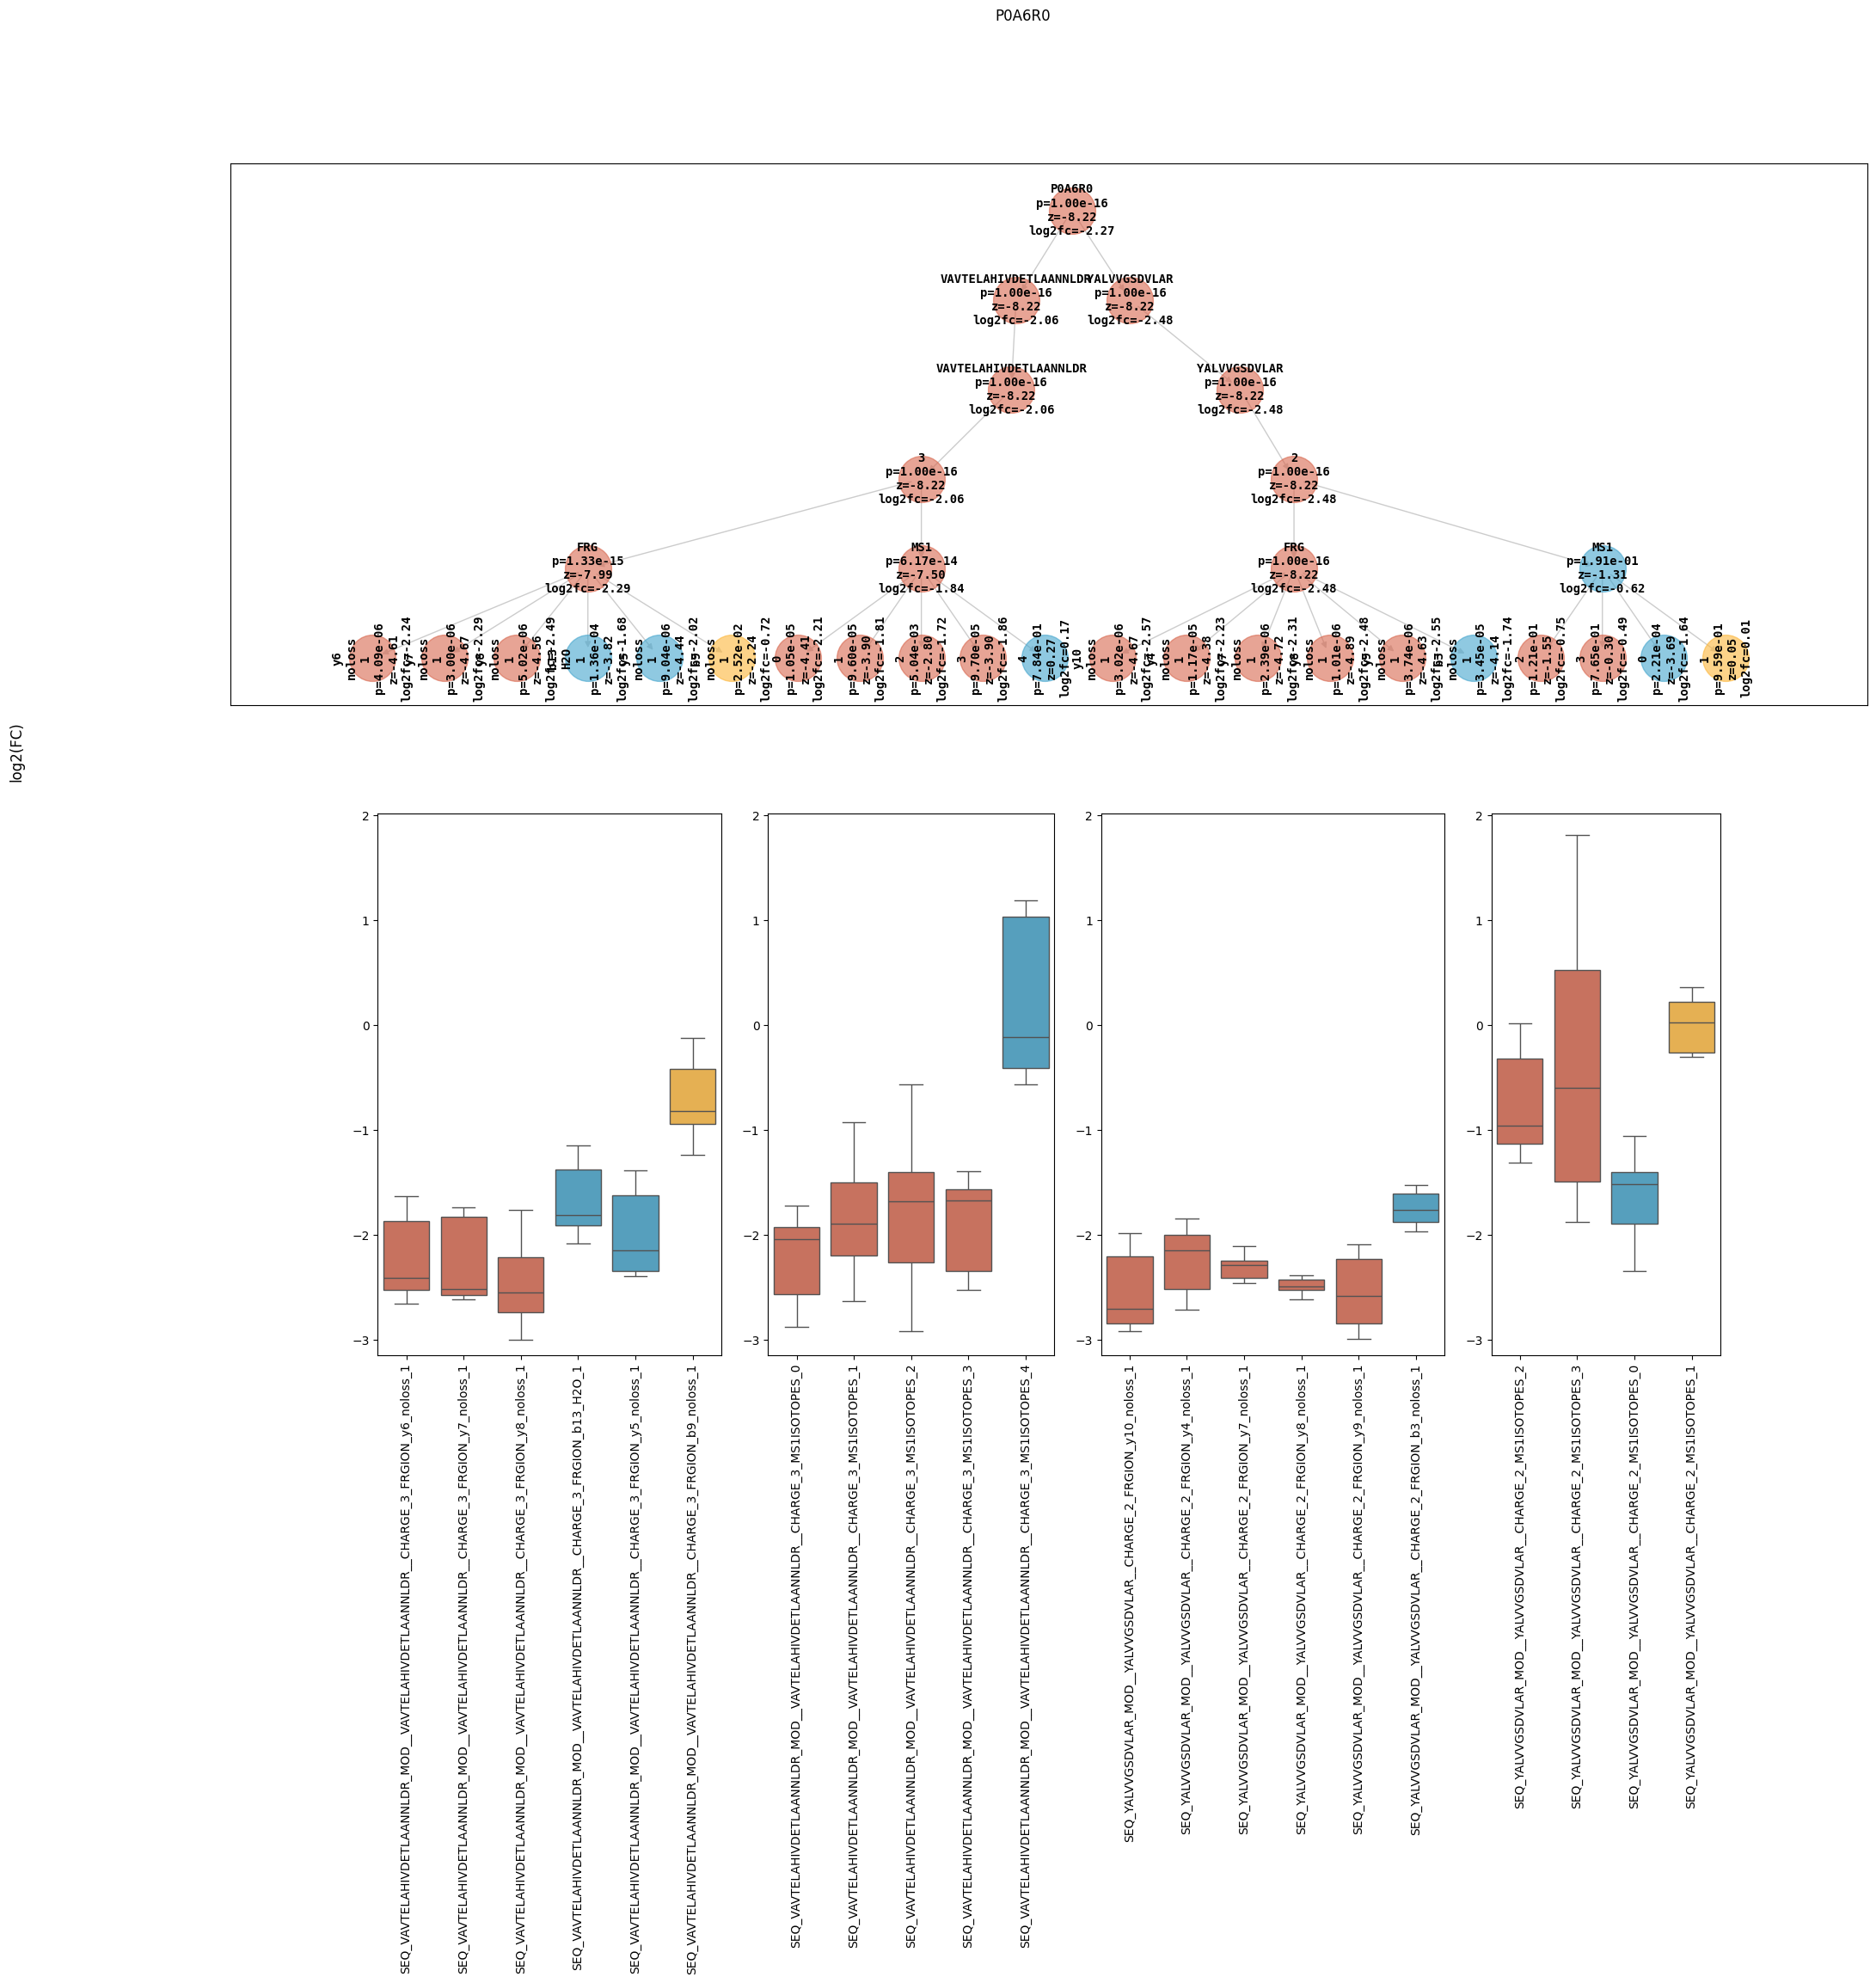

In [1]:
from IPython.display import display
import alphaquant.plotting.fcviz as aq_fcviz
import alphaquant.plotting.tree_and_fc_viz as aq_tree_and_fc_viz
import alphaquant.utils.utils as aq_utils
import os

# Load data from ./data/example_tree_data (relative to this notebook)
RESULTS_DIR = "./data/example_tree_data"
SAMPLEMAP = os.path.join(RESULTS_DIR, "samples.map.tsv")

# Read condition-pair tree and quantification info
condpair_tree = aq_utils.read_condpair_tree("S1", "S2", results_folder=RESULTS_DIR)
quant_info = aq_fcviz.CondpairQuantificationInfo(("S1", "S2"), RESULTS_DIR, SAMPLEMAP)
protein2node = {node.name: node for node in condpair_tree.children}

# Pick an example protein to display
example_protein = "P0A6R0"

# Build and display the combined tree + fold-change plot with node annotations (no saving)
plot_config = aq_fcviz.PlotConfig(
    tree_level="base",
    rescale_factor_x=0.9,
    rescale_factor_y=0.9,
    show_node_annotations=True,
    node_annotation_attributes=["p_val", "z_val", "fc"],
    node_annotation_formats={
        "p_val": "p={:.2e}",
        "z_val": "z={:.2f}",
        "fc": "log2fc={:.2f}",
    },
    node_fontsize=12,
)
plotter = aq_tree_and_fc_viz.CombinedTreeAndFCPlotter(
    protein2node[example_protein],
    quant_info,
    plot_config,
)
